In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
#task 1

In [4]:
# Load dataset
data = pd.read_csv("Position_Salaries.csv") 

In [5]:
# Display first few rows
print("First 5 rows:\n", data.head()) 

First 5 rows:
             Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [6]:
# Dataset info
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None


In [7]:
# Summary statistics
print("\nSummary Statistics:")
print(data.describe()) 


Summary Statistics:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


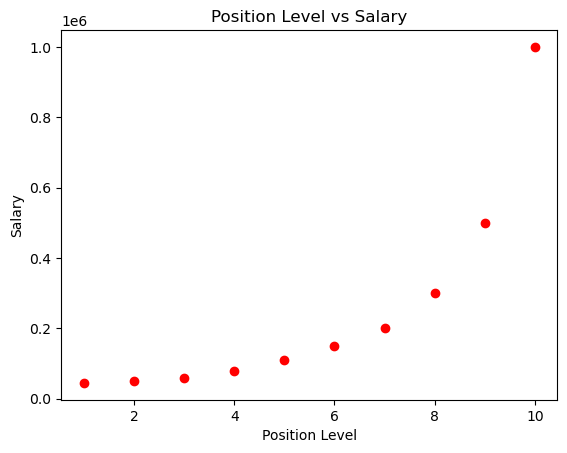

In [8]:
# Scatter plot
plt.scatter(data['Level'], data['Salary'], color='red')
plt.title("Position Level vs Salary")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [9]:
#task 2

In [10]:
X = data[['Level']].values  # Independent variable (2D array)
y = data['Salary'].values   # Dependent variable

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10, 1)
y shape: (10,)


In [11]:
#task 3

In [12]:
from sklearn.linear_model import LinearRegression 

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [14]:
# Predictions
y_pred_lin = lin_reg.predict(X)

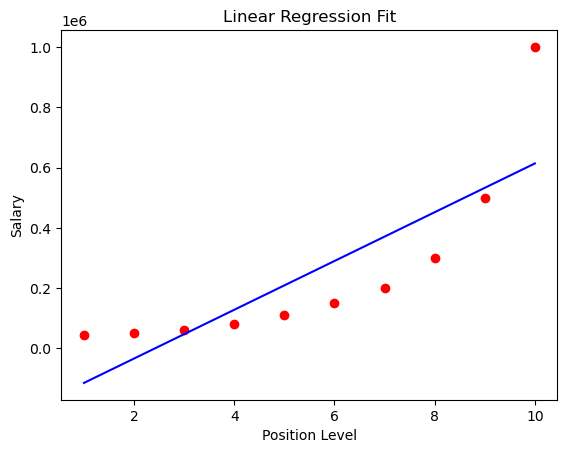

In [15]:
# Visualization
plt.scatter(X, y, color='red')
plt.plot(X, y_pred_lin, color='blue')
plt.title("Linear Regression Fit")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [16]:
#task 4

In [17]:
from sklearn.preprocessing import PolynomialFeatures 

In [18]:
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    lin_reg_poly = LinearRegression()
    lin_reg_poly.fit(X_poly, y)
    
    y_pred_poly = lin_reg_poly.predict(X_poly)

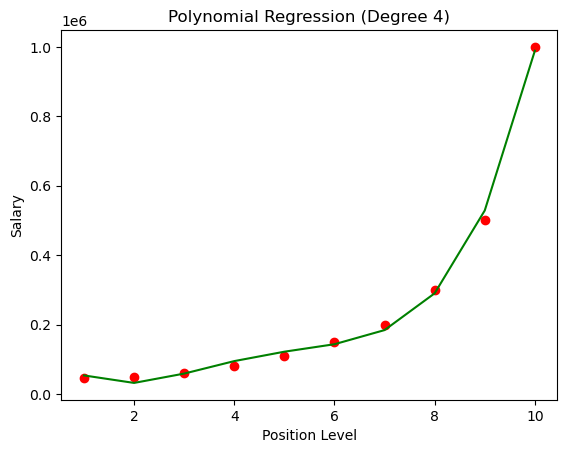

In [20]:
# Plot
plt.scatter(X, y, color='red')
plt.plot(X, y_pred_poly, color='green')
plt.title(f"Polynomial Regression (Degree {degree})")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [21]:
#task 5

In [22]:
from sklearn.metrics import mean_squared_error, r2_score 

In [23]:
def evaluate_model(model, X, y, poly=None):
    if poly:
        X_trans = poly.transform(X)
    else:
        X_trans = X
    y_pred = model.predict(X_trans)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    return mse, rmse, r2

In [24]:
# Linear regression evaluation
mse_lin, rmse_lin, r2_lin = evaluate_model(lin_reg, X, y)

print("Linear Regression -> MSE:", mse_lin, "RMSE:", rmse_lin, "R2:", r2_lin)


Linear Regression -> MSE: 26695878787.878788 RMSE: 163388.73519272613 R2: 0.6690412331929895


In [25]:
# Polynomial regression evaluations
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    lin_reg_poly = LinearRegression()
    lin_reg_poly.fit(X_poly, y)
    
    mse, rmse, r2 = evaluate_model(lin_reg_poly, X, y, poly)
    print(f"Polynomial Regression (Degree {degree}) -> MSE: {mse}, RMSE: {rmse}, R2: {r2}")


Polynomial Regression (Degree 2) -> MSE: 6758833333.333334, RMSE: 82212.12400451246, R2: 0.9162082221443942
Polynomial Regression (Degree 3) -> MSE: 1515662004.6620033, RMSE: 38931.504012329184, R2: 0.9812097727913367
Polynomial Regression (Degree 4) -> MSE: 210343822.8438184, RMSE: 14503.234909626832, R2: 0.9973922891706614


In [26]:
#task 6

In [27]:
degree = 4
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y) 

LinearRegression()

In [29]:
# Create fine grid
X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = lin_reg_poly.predict(X_grid_poly)

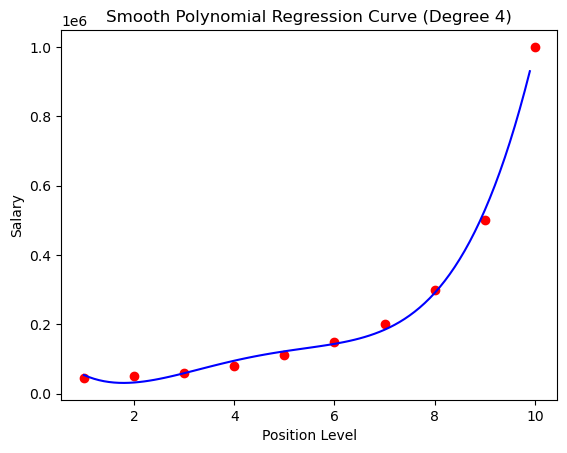

In [30]:
# Plot
plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred, color='blue')
plt.title(f"Smooth Polynomial Regression Curve (Degree {degree})")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [31]:
#task 7

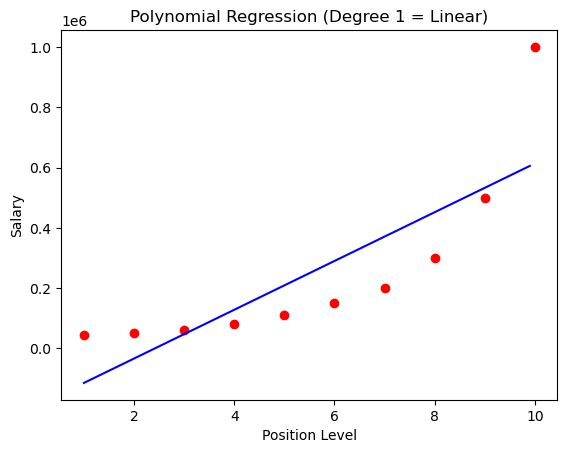

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly1 = PolynomialFeatures(degree=1)
X_poly1 = poly1.fit_transform(X)

lin_reg1 = LinearRegression()
lin_reg1.fit(X_poly1, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred1 = lin_reg1.predict(poly1.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred1, color='blue')
plt.title("Polynomial Regression (Degree 1 = Linear)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


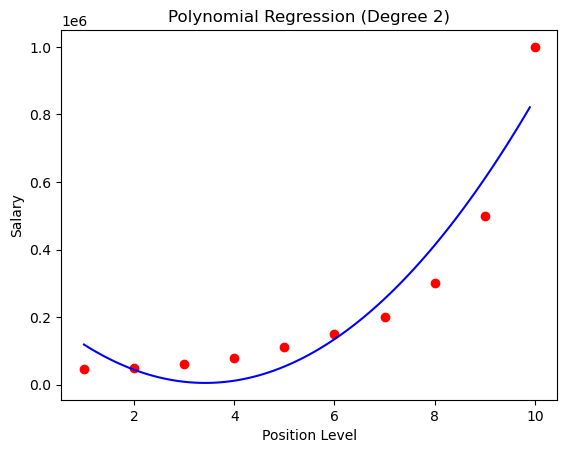

In [37]:
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

lin_reg2 = LinearRegression()
lin_reg2.fit(X_poly2, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred2 = lin_reg2.predict(poly2.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred2, color='blue')
plt.title("Polynomial Regression (Degree 2)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


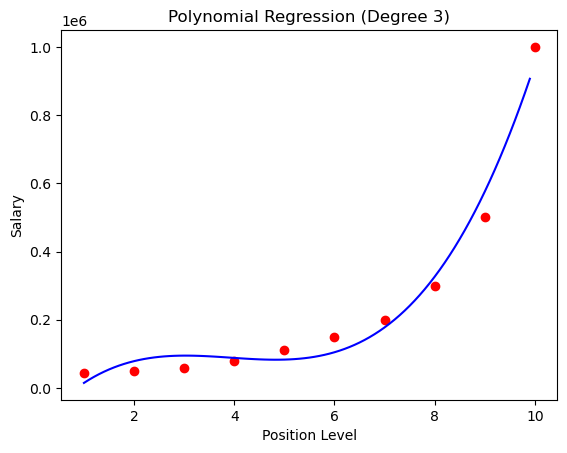

In [38]:
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

lin_reg3 = LinearRegression()
lin_reg3.fit(X_poly3, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred3 = lin_reg3.predict(poly3.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred3, color='blue')
plt.title("Polynomial Regression (Degree 3)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


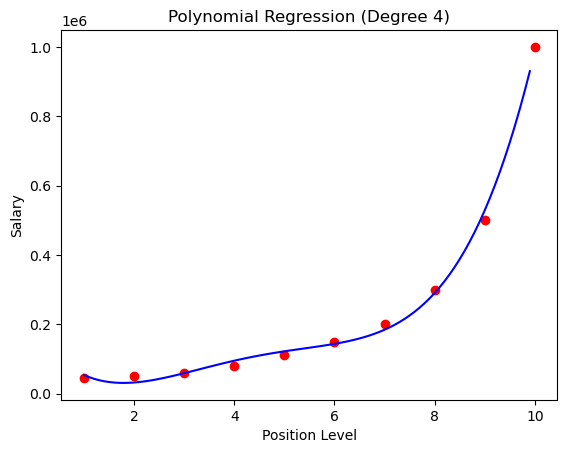

In [39]:
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)

lin_reg4 = LinearRegression()
lin_reg4.fit(X_poly4, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred4 = lin_reg4.predict(poly4.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred4, color='blue')
plt.title("Polynomial Regression (Degree 4)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


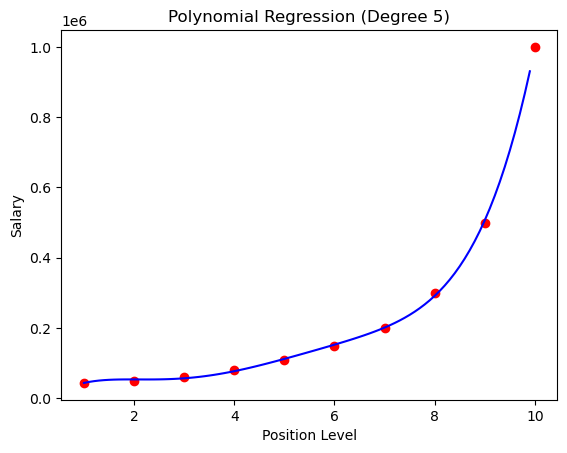

In [40]:
poly5 = PolynomialFeatures(degree=5)
X_poly5 = poly5.fit_transform(X)

lin_reg5 = LinearRegression()
lin_reg5.fit(X_poly5, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred5 = lin_reg5.predict(poly5.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred5, color='blue')
plt.title("Polynomial Regression (Degree 5)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


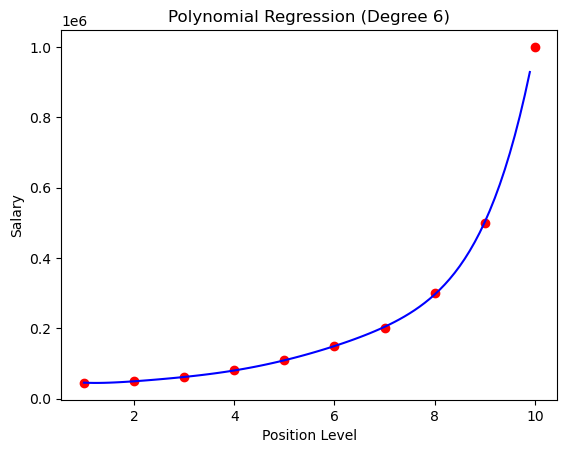

In [41]:
poly6 = PolynomialFeatures(degree=6)
X_poly6 = poly6.fit_transform(X)

lin_reg6 = LinearRegression()
lin_reg6.fit(X_poly6, y)

X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1,1)
y_grid_pred6 = lin_reg6.predict(poly6.transform(X_grid))

plt.scatter(X, y, color='red')
plt.plot(X_grid, y_grid_pred6, color='blue')
plt.title("Polynomial Regression (Degree 6)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()


In [42]:
for degree in range(1, 7):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    lin_reg_poly = LinearRegression()
    lin_reg_poly.fit(X_poly, y) 

In [43]:
    X_grid = np.arange(min(X[:,0]), max(X[:,0]), 0.1).reshape(-1, 1)
    y_grid_pred = lin_reg_poly.predict(poly.transform(X_grid))

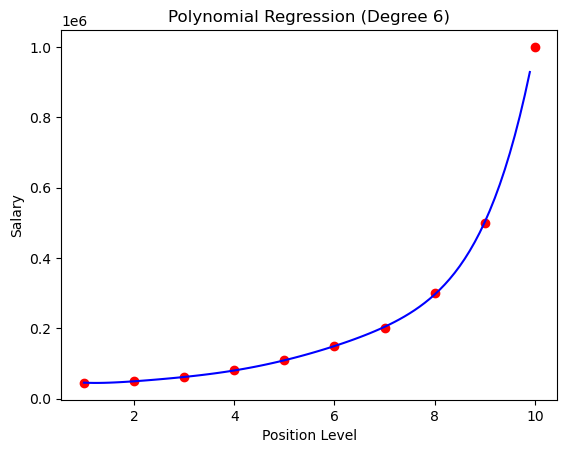

In [44]:
    plt.scatter(X, y, color='red')
    plt.plot(X_grid, y_grid_pred, color='blue')
    plt.title(f"Polynomial Regression (Degree {degree})")
    plt.xlabel("Position Level")
    plt.ylabel("Salary")
    plt.show() 